# Sales Performance Analysis

## Objective

The goal of this analysis is to understand the sales and profitability
performance of the business and identify products, categories, discounts,
branches, and customer behaviors that have the greatest impact on revenue
and profit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
pd.set_option("display.max_columns", None)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

sns.set(color_codes=True)

## Load Cleaned Dataset

In [2]:
sales = pd.read_csv(
    "../data/sales_clean.csv", 
    parse_dates=["order_date"]
)

sales.head()

,order_id,customer_id,order_date,order_status,order_priority,payment_method,quantity,final_price_at_order_time,cost_price_at_order_time,branch_id,discount,product_id,product_name,category_id,category_name,revenue,cost,profit,profit_margin,year,month,month_name,year_month
0,25263,1599,2026-02-01,Received,High,In-App Wallet,5,1330.92,78.83,15,0.25,358,NitroBlade Ultra,28,Laptops,6654.60,394.15,6260.45,94.077029,2026,2,February,2026-02
1,25263,1599,2026-02-01,Received,High,In-App Wallet,5,1330.92,53.99,20,0.25,358,NitroBlade Ultra,28,Laptops,6654.60,269.95,6384.65,95.943408,2026,2,February,2026-02
2,25263,1599,2026-02-01,Received,High,In-App Wallet,3,1330.92,61.28,13,0.25,358,NitroBlade Ultra,28,Laptops,3992.76,183.84,3808.92,95.395666,2026,2,February,2026-02
3,25263,1599,2026-02-01,Received,High,In-App Wallet,4,1330.92,78.12,16,0.25,358,NitroBlade Ultra,28,Laptops,5323.68,312.48,5011.20,94.130376,2026,2,February,2026-02
4,25263,1599,2026-02-01,Received,High,In-App Wallet,5,1330.92,75.55,11,0.25,358,NitroBlade Ultra,28,Laptops,6654.60,377.75,6276.85,94.323475,2026,2,February,2026-02


# KPI Definitions

To evaluate DBKala's sales performance, profitability, customer activity, and operational performance, the following Key Performance Indicators (KPIs) are defined.

Since the dataset is at the **order-item level**, order-related KPIs are calculated using unique `order_id` values rather than the number of rows in the dataset.

| KPI                           | Definition                                            | Business Purpose                                                                         |
| ----------------------------- | ----------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| **Total Revenue**             | Sum of the revenue generated from all order items.    | Measures the overall sales volume and business revenue.                                  |
| **Total Cost**                | Sum of the cost associated with all sold items.       | Measures the total cost of goods sold and provides the basis for profitability analysis. |
| **Total Profit**              | `Total Revenue − Total Cost`                          | Measures the overall financial profit generated by sales.                                |
| **Profit Margin**             | `(Total Profit / Total Revenue) × 100`                | Measures how much of the generated revenue is retained as profit.                        |
| **Total Orders**              | Number of unique `order_id` values.                   | Measures the overall volume of customer orders.                                          |
| **Unique Customers**          | Number of unique `customer_id` values.                | Measures the size of the customer base.                                                  |
| **Units Sold**                | Sum of the `quantity` column.                         | Measures the total number of products sold.                                              |
| **Average Order Value (AOV)** | `Total Revenue / Total Orders`                        | Measures the average revenue generated per order.                                        |
| **Average Units per Order**   | `Units Sold / Total Orders`                           | Measures the average number of items included in each order.                             |
| **Loss Transactions**         | Number of order-item transactions where `Profit < 0`. | Identifies sales transactions that generate a financial loss.                            |
| **Loss Rate**                 | `(Loss Transactions / Total Transactions) × 100`      | Measures the proportion of transactions that are loss-making.                            |
| **Average Profit per Order**  | `Total Profit / Total Orders`                         | Measures the average profit generated per order.                                         |
**Reveneu per Customer**  | `total_revenue / unique_customers` | Measures the average revenue generated by each unique customer and provides an indication of customer value.


### KPI Categories

The KPIs are grouped into four main business dimensions:

#### 1. Sales Performance

* Total Revenue
* Total Orders
* Units Sold
* Average Order Value (AOV)

These KPIs help evaluate the scale and volume of sales.

#### 2. Profitability

* Total Cost
* Total Profit
* Profit Margin
* Average Profit per Order
* Loss Rate
* Loss Transactions

These KPIs help assess whether sales are generating sustainable profits.

#### 3. Customer Activity

* Unique Customers
* Average Units per Order
* Reveneu per Customer

These metrics provide an overview of customer activity and purchasing behavior.


> **Note:** KPI calculations will be performed on the cleaned dataset. Any anomalous records identified during the data-quality assessment, such as invalid dates or invalid cost values, should be addressed before calculating the final KPIs.


## KPI Calculation

In [4]:
# Core KPIs

total_revenue = sales["revenue"].sum()
total_cost = sales["cost"].sum()
total_profit = sales["profit"].sum()

total_orders = sales["order_id"].nunique()
unique_customers = sales["customer_id"].nunique()
unit_sold = sales["quantity"].sum()

In [5]:
# Drived KPIs

profit_margin = (total_profit / total_revenue) * 100

aov = total_revenue / total_orders

revenue_per_customer = total_revenue / unique_customers

avg_units_per_order = unit_sold / total_orders

avg_profit_per_order = total_profit / total_orders

loss_transactions = (sales["profit"] < 0).sum()

loss_rate = (loss_transactions / len(sales)) * 100

In [6]:
kpis = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Cost",
        "Total Profit",
        "Profit Margin",
        "Total Orders",
        "Unique Customers",
        "Units Sold",
        "Average Order Value",
        "Average Units per Order",
        "Average Profit per Order",
        "Loss Transactions",
        "Loss Rate",
        "Revenue per Customer"
    ],
    "Value": [
        total_revenue,
        total_cost,
        total_profit,
        profit_margin,
        total_orders,
        unique_customers,
        unit_sold,
        aov,
        avg_units_per_order,
        avg_profit_per_order,
        loss_transactions,
        loss_rate,
        revenue_per_customer
    ]
})

## KPI Overview

The following KPIs provide a high-level overview of DBKala's overall sales performance, profitability, customer base, and transaction quality.

These KPIs serve as the baseline for the detailed business analysis in the following sections.

In [8]:
kpi_display = kpis.copy()

percentage_kpis = ["Profit Margin", "Loss Rate"]

integer_kpis = ["Total Orders", "Unique Customers", "Loss Transactions"]

for i, row in kpi_display.iterrows():
    kpi = row["KPI"]
    value = row["Value"]

    if kpi in percentage_kpis:
        kpi_display.loc[i, "Value"] = f"{value:,.2f}%"
    elif kpi in integer_kpis:
        kpi_display.loc[i, "Value"] = f"{value:,.0f}"    
    else:
        kpi_display.loc[i, "Value"] = f"{value:,.2f}"   

kpi_display

C:\Users\kavoshrayan\AppData\Local\Temp\ipykernel_2040\1452473402.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '395,659,500.36' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  kpi_display.loc[i, "Value"] = f"{value:,.2f}"


,KPI,Value
0,Total Revenue,"395,659,500.36"
1,Total Cost,"257,020,565.87"
2,Total Profit,"138,638,934.49"
3,Profit Margin,35.04%
4,Total Orders,"26,827"
5,Unique Customers,"1,987"
6,Units Sold,"783,414.00"
7,Average Order Value,"14,748.56"
8,Average Units per Order,29.20
9,Average Profit per Order,"5,167.89"


Define the custom functions for plot the analysis.

In [4]:
def plot_top_bar(
    data, 
    category_col,
    value_col,
    title,
    top_n=10,
    value_format="number",
    figsize=(10, 6)
):
    # select top n
    plot_df = data.sort_values(value_col, ascending=False).head(10)

    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=plot_df,
        x=value_col,
        y=category_col,
        palette="Blues_r",
        hue=category_col,
        legend=False
    )

    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=15
    )
    ax.set_xlabel(value_col.replace("_", " ").title())
    ax.set_ylabel(category_col.replace("_", " ").title())

    # Format x-axis
    if value_format == "million":
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
        )

        labels = [
            f"{value/1e6:.1f}M"
            for value in plot_df[value_col]
        ]

    elif value_format == "thousand":
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x/1e3:.1f}K")
        )

        labels = [
            f"{value/1e3:.1f}K"
            for value in plot_df[value_col]
        ]

    else:
        labels = [
            f"{value:,.0f}"
            for value in plot_df[value_col]
        ]

    # Value labels
    for i, (value, label) in enumerate(zip(plot_df[value_col], labels)
    ):
        ax.text(
            value,
            i,
            f" {label}",
            va="center",
            fontsize=10
        )

    sns.despine(left=True, bottom=True)

    plt.tight_layout()
    plt.show()

# Analysis

## 1. Sales Performance 
### 1.1 Sales Performance Over Time

**Business Question:**  
How has DBKala's sales performance changed over time?

To answer this question, we examine the yearly trends in:
- Revenue
- Orders
- Profit

Analyzing these metrics over time helps identify periods of growth, decline, and changes in overall business performance.

In [5]:
yearly_performance = sales.groupby("year").agg(
    revenue = ("revenue", "sum"),
    profit = ("profit", "sum"),
    orders = ("order_id", "nunique"),
    unit_sold = ("quantity", "sum")
).reset_index()

yearly_performance.style.format({
    "revenue": "{:,.2f}",
    "profit": "{:,.2f}",
    "orders": "{:,.0f}",
    "units_sold": "{:,.0f}"
})

,year,revenue,profit,orders,unit_sold
0,2020,"49,640,626.26","3,300,790.68","4,657",127653
1,2021,"49,513,931.58","3,159,744.18","4,746",127242
2,2022,"50,687,546.71","3,240,715.88","4,766",130695
3,2023,"48,156,508.68","3,211,066.93","4,529",123596
4,2024,"48,366,758.85","3,097,896.41","4,565",124537
5,2025,"21,104,169.04","1,323,894.13","1,962",53418
6,2026,"128,189,959.24","121,304,826.28","1,602",96273


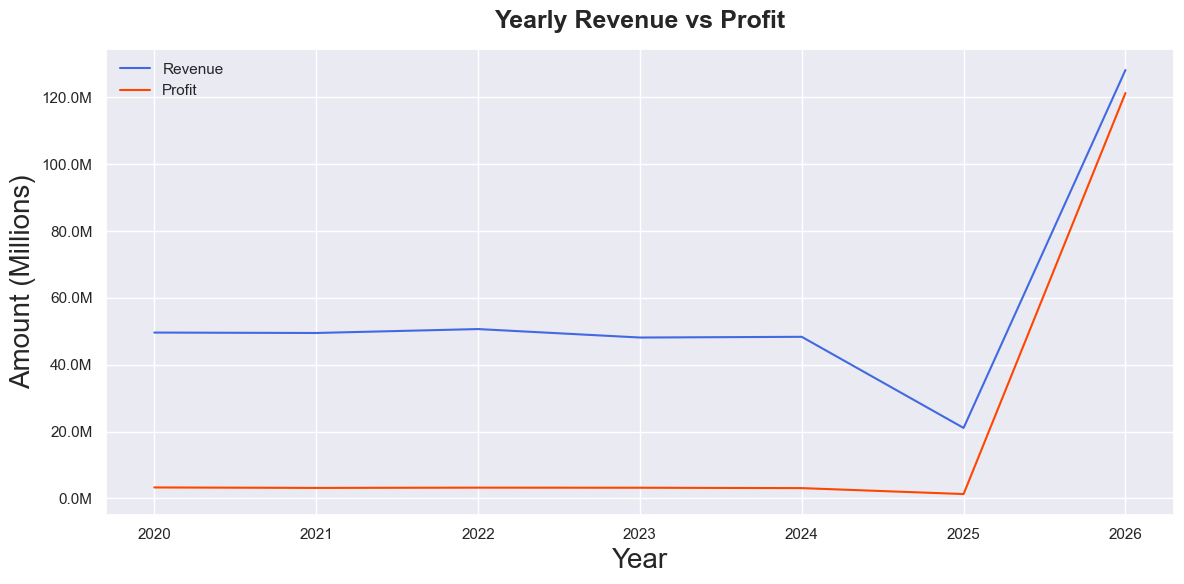

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(yearly_performance["year"], yearly_performance["revenue"], label='Revenue', color='royalblue')
plt.plot(yearly_performance["year"], yearly_performance["profit"], label='Profit', color='orangered')
plt.title(
    "Yearly Revenue vs Profit",
    fontsize=18,
    fontweight="bold",
    pad=15
)
plt.xlabel('Year', fontsize=20)
plt.ylabel('Amount (Millions)', fontsize=20)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)

plt.legend()
plt.tight_layout()
plt.show()

- The yearly performance shows a significant anomaly in 2026. Although the number of orders decreased substantially compared with previous years, revenue increased sharply and profit reached an unusually high level.
- This suggests that the 2026 records may contain anomalous pricing or cost values. The underlying transactions should therefore be investigated before interpreting the 2026 results as genuine business growth.

In [ ]:
profit_2026 = (
    sales[sales["year"] == 2026]
    .groupby("product_name")
    .agg(
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        profit=("profit", "sum"),
        units_sold=("quantity", "sum"),
        transactions=("order_id", "count")
    )
    .sort_values("profit", ascending=False)
)

profit_2026.head(15)

,revenue,cost,profit,units_sold,transactions
product_name,,,,,
NitroBlade Ultra,44448735.24,2445783.70,42002951.54,33397,8400
SurfaceBook Pro,32097685.94,1556012.99,30541672.95,24097,6000
SurfaceBook Vision,19369867.95,942520.89,18427347.06,14415,3600
MacBook Vision,19450446.31,1110569.13,18339877.18,14381,3600
SurfaceBook Infinity,12806922.70,795593.85,12011328.85,9581,2400
LittleStar Sweater,16301.10,34652.40,-18351.30,402,402


## 2. Product Performance

#### Questions

- Which products generate the most revenue?
- Which products generate the most profit?
- Which products sell the most units?
- Which products have the highest/lowest profitability?
- Are high-revenue products also highly profitable?
- Which products are loss-making and require attention?

In [10]:
product_performance = sales.groupby("product_name").agg(
    revenue=("revenue", "sum"),
    profit = ("profit", "sum"),
    units_sold=("quantity", "sum"),
    transactions=("order_id", "nunique")
).reset_index()

product_performance["profit_margin"] = (
    product_performance["profit"] / product_performance["revenue"] * 100
)

product_performance.head(10)

,product_name,revenue,profit,units_sold,transactions,profit_margin
0,Alpine Hoodie,43169.94,4196.99,850,152,9.722020
1,Alpine Jacket,40695.29,3425.40,845,155,8.417190
2,Alpine Jeans,46184.99,4658.96,938,164,10.087606
3,Alpine Pants,41660.21,1435.56,873,156,3.445878
4,Alpine Shirt,45526.11,3960.12,963,169,8.698569
5,Alpine Shorts,46890.97,2220.93,962,173,4.736370
6,Alpine Sweater,54058.39,2662.98,1116,195,4.926118
7,Alpine Tee,37943.81,1733.24,824,143,4.567912
8,AmbientGlow Blanket,263501.36,11862.96,1769,315,4.502049
9,AmbientGlow Cushion,254690.18,13220.69,1645,288,5.190891


### 2.1 Top Products by Revenue 

Revenue is used as the first product-level performance indicator to identify
which products contribute the most to overall sales.

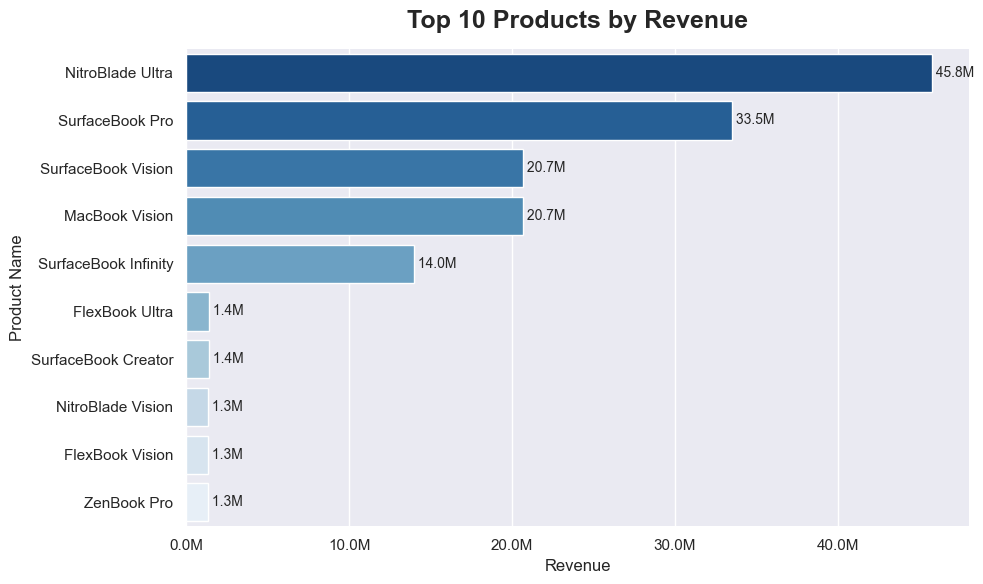

In [12]:
plot_top_bar(
    product_performance,
    category_col="product_name",
    value_col="revenue",
    title="Top 10 Products by Revenue",
    top_n=10,
    value_format="million"
)

**NitroBlade Ultra** generates the highest revenue among all products, followed by **SurfaceBook Pro** and **SurfaceBook Vision**.

### 2.2 Top Products by Profit

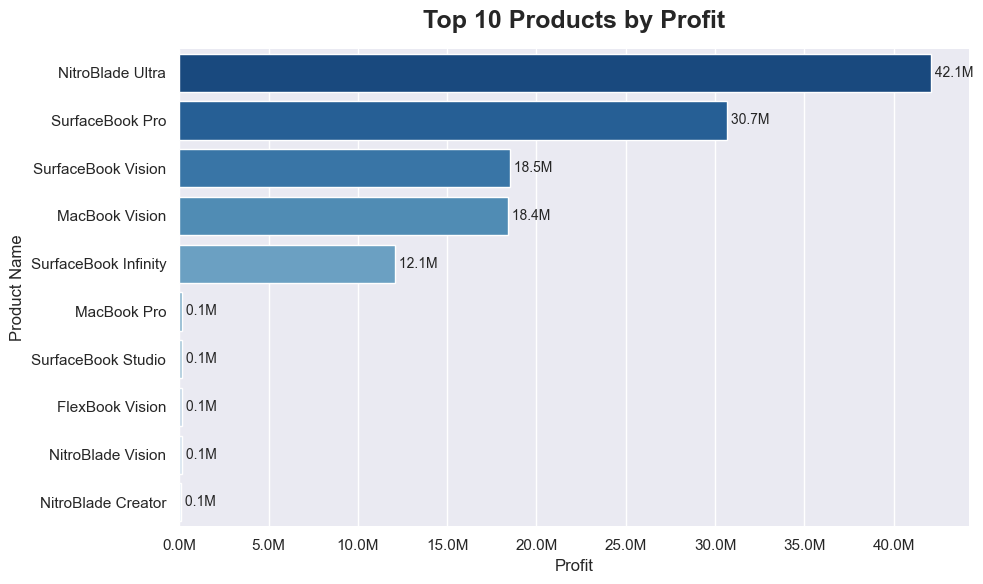

In [13]:
plot_top_bar(
    product_performance,
    category_col="product_name",
    value_col="profit",
    title="Top 10 Products by Profit",
    top_n=10,
    value_format="million"
)

- The profit analysis shows a highly concentrated profit distribution across products.

- **NitroBlade Ultra** generates the highest profit, followed by **SurfaceBook Pro**, **SurfaceBook Vision**, and **MacBook Vision**. The top five products contribute substantially more profit than the remaining products in the top 10.

- This indicates that a small group of products is responsible for a large share of the business profit, making these products particularly important for revenue and profitability management.

However, this result should be interpreted with caution because the dataset contains unusually high profitability in 2026. Therefore, the concentration of profit may be partially driven by data anomalies or unusual pricing/cost patterns in that period.

### 2.3 Loss-Making Products

<!-- Identifying the least profitable products helps detect products that
generate losses and may require pricing, cost, or inventory review. -->

In [77]:
loss_products = (
    product_performance[
        product_performance["profit"] < 0
    ]
    .sort_values("profit")
)    

loss_products.head()

,product_name,revenue,profit,units_sold,transactions,profit_margin
253,LittleStar Sweater,51668.04,-14642.06,1558,616,-28.338718
36,Breeze Jacket,47194.44,-399.87,982,170,-0.847282


In [108]:
loss_product_analysis = (
    sales[sales["product_name"].isin(loss_products["product_name"])]
    .assign(
        below_cost=lambda x:
        x["final_price_at_order_time"] < x["cost_price_at_order_time"]
    )
    .groupby(["product_name",  "discount"])
    .agg(
        transactions=("order_id", "nunique"),
        units_sold=("quantity", "sum"),
        avg_selling_price=("final_price_at_order_time", "mean"),
        avg_cost=("cost_price_at_order_time", "mean"),
        avg_discount=("discount", "mean"),
        total_revenue=("revenue", "sum"),
        total_cost=("cost", "sum"),
        total_profit=("profit", "sum"),
        below_cost_transactions=("below_cost", "sum"),
    )
)

loss_product_analysis["profit_margin"] = (
    loss_product_analysis["total_profit"]
    / loss_product_analysis["total_revenue"] * 100
)

loss_product_analysis["below_cost_rate"] = (
    loss_product_analysis["below_cost_transactions"]
    / loss_product_analysis["transactions"] * 100
)

loss_product_analysis

,,transactions,units_sold,avg_selling_price,avg_cost,avg_discount,total_revenue,total_cost,total_profit,below_cost_transactions,profit_margin,below_cost_rate
product_name,discount,,,,,,,,,,,
Breeze Jacket,0.27,170,982,48.107059,47.632235,0.27,47194.44,47594.31,-399.87,77,-0.847282,45.294118
LittleStar Sweater,0.25,616,1558,37.056039,65.837386,0.25,51668.04,66310.10,-14642.06,480,-28.338718,77.922078


- **LittleStar Sweater** is a structurally loss-making product, with nearly **78%** of its transactions occurring below cost.

### 2.4 Volume vs Profitability

This analysis compares product sales volume with profitability to identify high-performing products, inefficient high-volume products, and potential growth opportunities.


In [109]:
product_performance.sort_values("units_sold", ascending=False).head(10)

,product_name,revenue,profit,units_sold,transactions,profit_margin
314,NitroBlade Ultra,45772596.10,42090854.02,34398,1381,91.956449
531,SurfaceBook Pro,33541181.63,30671027.61,25183,1395,91.442895
534,SurfaceBook Vision,20683624.50,18490826.73,15369,1371,89.398387
270,MacBook Vision,20666337.83,18418521.33,15290,1370,89.123295
529,SurfaceBook Infinity,14008754.75,12102050.15,10486,1363,86.389193
11,AmbientGlow Frame,299096.88,19984.58,1946,357,6.681641
8,AmbientGlow Blanket,263501.36,11862.96,1769,315,4.502049
179,GreenLeaf Blanket,273050.31,19438.18,1745,307,7.118901
183,GreenLeaf Lamp,263596.99,19101.47,1735,309,7.246467
279,ModernArt Diffuser,269924.69,16106.77,1722,302,5.967135


In [112]:
volume_threshold = product_performance["units_sold"].median()
margin_threshold = np.round(product_performance["profit_margin"].median())

print("Volume threshold:", volume_threshold)
print("Profit margin threshold:", margin_threshold)

Volume threshold: 1161.0
Profit margin threshold: 6.0


#### Define the thresholds 

We defined thresholds about *units_sold* and *profit_margin* to classify products based on their number of solds and profit margins.

Products are segmented based on sales volume and profit margin to evaluate overall portfolio performance.

In [128]:
segments = [
        "High Volume / High Margin",
        "High Volume / Low Margin",
        "Low Volume / High Margin"
    ]
product_performance["segment"] = np.select(
    [
        (product_performance["units_sold"] >= volume_threshold) & 
        (product_performance["profit_margin"] >= margin_threshold),

        (product_performance["units_sold"] >= volume_threshold) &
        (product_performance["profit_margin"] < margin_threshold),

        (product_performance["units_sold"] < volume_threshold) &
        (product_performance["profit_margin"] >= margin_threshold)
    ],
    segments,
    default="Low Volume / Low Margin"
)

product_performance.sort_values(
    ["segment", "profit"],
    ascending=[True, False]
).head(10)

,product_name,revenue,profit,units_sold,transactions,profit_margin,segment
314,NitroBlade Ultra,45772596.10,42090854.02,34398,1381,91.956449,High Volume / High Margin
531,SurfaceBook Pro,33541181.63,30671027.61,25183,1395,91.442895,High Volume / High Margin
534,SurfaceBook Vision,20683624.50,18490826.73,15369,1371,89.398387,High Volume / High Margin
270,MacBook Vision,20666337.83,18418521.33,15290,1370,89.123295,High Volume / High Margin
529,SurfaceBook Infinity,14008754.75,12102050.15,10486,1363,86.389193,High Volume / High Margin
334,OakCraft Sofa,1043362.26,88277.39,1329,237,8.460857,High Volume / High Margin
325,NordicEdge Desk,981168.96,83774.80,1285,244,8.538264,High Volume / High Margin
458,SoftRelax Shelf,914795.69,79773.32,1171,219,8.720343,High Volume / High Margin
380,PureOak Sofa,887076.23,72059.26,1173,216,8.123232,High Volume / High Margin
327,NordicEdge Sofa,1047263.28,70755.10,1312,229,6.756190,High Volume / High Margin


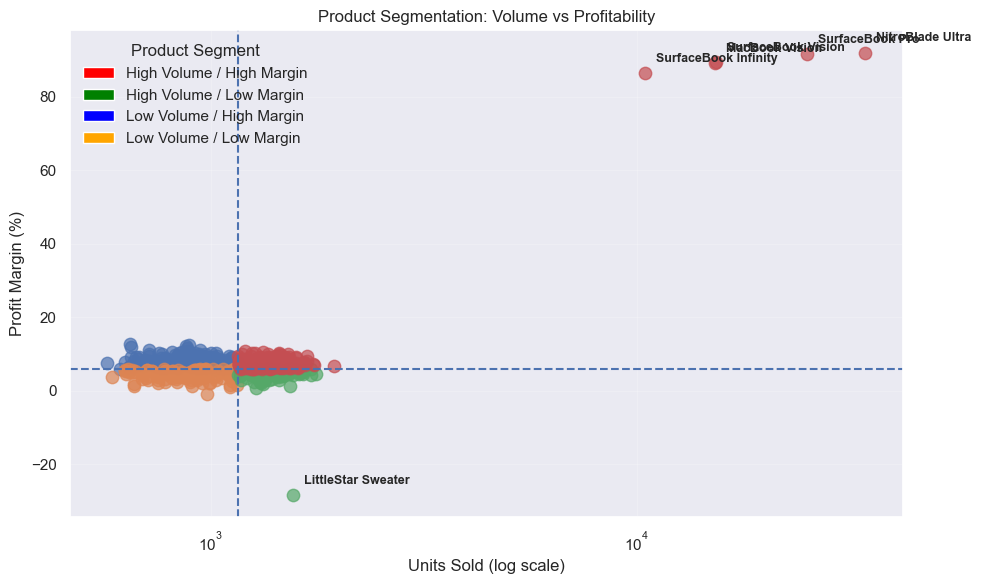

In [132]:
from matplotlib.patches import Patch

important_products = [
    "NitroBlade Ultra",
    "SurfaceBook Pro",
    "SurfaceBook Vision",
    "MacBook Vision",
    "SurfaceBook Infinity",
    "LittleStar Sweater"
]

fig, ax = plt.subplots(figsize=(10, 6))

for segment in product_performance["segment"].unique():
    data = product_performance[product_performance["segment"] == segment]

    ax.scatter(
        data["units_sold"],
        data["profit_margin"],
        s=80,
        alpha=0.7
    )

# Median lines
ax.axvline(
    volume_threshold,
    linestyle="--",
    linewidth=1.5
)

ax.axhline(
    margin_threshold,
    linestyle="--",
    linewidth=1.5
)

# add labels 
for _, row in product_performance[
    product_performance["product_name"].isin(important_products)
].iterrows():
    ax.annotate(
        row["product_name"],
        (row["units_sold"], row["profit_margin"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold"
    )

# log scale
plt.xscale("log")

ax.set_xlabel("Units Sold (log scale)")
ax.set_ylabel("Profit Margin (%)")
ax.set_title("Product Segmentation: Volume vs Profitability")

legend_elements = [
    Patch(label="High Volume / High Margin", facecolor="red"),
    Patch(label="High Volume / Low Margin", facecolor="green"),
    Patch(label="Low Volume / High Margin", facecolor="blue"),
    Patch(label="Low Volume / Low Margin", facecolor="orange")
]
ax.legend(
    handles=legend_elements,
    title="Product Segment",
    loc="upper left")

ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

- Product performance is highly concentrated. A small group of products combines high sales volume with exceptionally high profit margins, while most products operate at considerably lower margins.
- The concentration of extreme-margin products should be investigated further, particularly because of the identified 2026 data anomalies.

## 3.  Customer Analysis

In [15]:
customer_performance = sales.groupby("customer_id").agg(
    revenue = ("revenue", "sum"),
    profit = ("profit", "sum"),
    orders = ("order_id", "nunique"),
    unit_sold = ("quantity", "sum")
).reset_index()

customer_performance["profit_margin"] = (
    customer_performance["profit"] / customer_performance["revenue"] * 100
)

customer_performance.sort_values(
    "revenue",
    ascending=False
).head(10)

,customer_id,revenue,profit,orders,unit_sold,profit_margin
1373,1374,669776.30,334836.73,35,1062,49.992323
365,366,643340.91,316164.14,32,1035,49.144106
114,115,634665.29,314441.90,29,934,49.544524
1178,1179,634193.70,331869.59,29,1005,52.329374
304,305,620417.53,332002.16,24,844,53.512698
181,182,614487.51,357269.27,24,912,58.141014
263,264,609720.02,326148.88,26,1017,53.491581
1493,1494,603663.21,311238.01,29,916,51.558221
8,9,602698.17,327152.33,23,815,54.281288
582,583,601170.03,312554.31,23,838,51.991000


### 3.1 RFM Analysis

- Recency : The number of days since a customer's most recent purchase. Lower values indicate more recent activity.

- Frequency : The total number of unique orders placed by a customer. Higher values indicate more frequent purchasing.

- Monetary : The total revenue generated by a customer. Higher values indicate greater customer value.


In [29]:
rfm = sales.groupby("customer_id").agg(
    last_purchase=("order_date", "max"),
    frequency=("order_id", "nunique"),
    monetary=("revenue", "sum")
).reset_index()

refrence_date = sales["order_date"].max()
print(f"Last purchus date : {refrence_date}")

rfm["recency"] = (
    refrence_date - rfm["last_purchase"]
).dt.days 


rfm.head()

Last purchus date : 2026-02-20 00:00:00


,customer_id,last_purchase,frequency,monetary,recency
0,1,2024-03-13,10,62547.50,709
1,2,2026-02-20,13,454440.17,0
2,3,2024-11-05,4,25994.29,472
3,4,2023-10-05,8,44103.79,869
4,5,2025-04-19,17,149043.78,307


In [26]:
rfm[["recency", "frequency", "monetary"]].describe()

,recency,frequency,monetary
count,1987.000000,1987.000000,1987.000000
mean,376.420232,13.501258,199124.056548
std,315.088258,6.276234,146619.302557
min,0.000000,1.000000,66.000000
25%,276.000000,9.000000,94394.235000
50%,343.000000,13.000000,157017.840000
75%,471.000000,18.000000,245995.070000
max,2217.000000,42.000000,669776.300000


#### Recency
Mean: 376 days
Median: 343 days
Minimum: 0 days
Maximum: 2,217 days

The large range suggests that customer activity is highly uneven. Some customers purchased very recently, while others have not purchased for several years.

#### Frequency
Mean: 13.5 orders
Median: 13 orders
Range: 1 – 42 orders

So the typical customer has around 13 orders, while the most frequent customers have up to 42 orders.

#### Monetary
Mean: 199,124
Median: 157,018
Maximum: 669,776

The mean being considerably higher than the median indicates that a relatively small group of customers generates substantially more revenue than the typical customer.

In [27]:
rfm.sort_values("monetary", ascending=False).head(10)

,customer_id,last_purchase,frequency,monetary,recency
1373,1374,2026-02-20,35,669776.30,0
365,366,2026-02-20,32,643340.91,0
114,115,2026-02-20,29,634665.29,0
1178,1179,2026-02-20,29,634193.70,0
304,305,2026-02-20,24,620417.53,0
181,182,2026-02-20,24,614487.51,0
263,264,2026-02-20,26,609720.02,0
1493,1494,2026-02-20,29,603663.21,0
8,9,2026-02-20,23,602698.17,0
582,583,2026-02-20,23,601170.03,0


### Calculate revenue concentration

In [31]:
total_revenue = rfm["monetary"].sum()

top_10_revenue = rfm.nlargest(10, "monetary")["monetary"].sum()

top_10_pct = top_10_revenue / total_revenue * 100

print(f"Top 10 customers revenue share: {top_10_pct:.2f}%")

Top 10 customers revenue share: 1.58%


In [32]:
concentration = pd.DataFrame({
    "Customer Group": ["Top 1%", "Top 5%", "Top 10%", "Bottom 50%"],
    "Revenue Share": [
        rfm.nlargest(max(1, int(len(rfm) * 0.01)), "monetary")["monetary"].sum() / total_revenue * 100,
        rfm.nlargest(max(1, int(len(rfm) * 0.05)), "monetary")["monetary"].sum() / total_revenue * 100,
        rfm.nlargest(max(1, int(len(rfm) * 0.10)), "monetary")["monetary"].sum() / total_revenue * 100,
        rfm.nsmallest(int(len(rfm) * 0.50), "monetary")["monetary"].sum() / total_revenue * 100
    ]
})

concentration

,Customer Group,Revenue Share
0,Top 1%,2.917906
1,Top 5%,13.745394
2,Top 10%,25.723393
3,Bottom 50%,22.786069


- Revenue is relatively well distributed across the customer base.
- The top 10% of customers account for approximately 25.7% of total revenue, while the bottom 50% contribute 22.8%. 
- This indicates that the business is not strongly dependent on a small group of high-value customers, suggesting a relatively diversified customer revenue base.

### 3.2 Repeat Customer Analysis



In [34]:
customer_performance["customer_type"] = np.where(
    customer_performance["orders"] == 1, 
    "One-time Customer",
    "Repeat Customer"
)

customer_type_summary = customer_performance.groupby("customer_type").agg(
    customers=("customer_id", "nunique"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
).reset_index()

customer_type_summary["customer_share"] = (
    customer_type_summary["customers"] 
    / customer_type_summary["customers"].sum() * 100
)

customer_type_summary["revenue_share"] = (
    customer_type_summary["revenue"]
    / customer_type_summary["revenue"].sum() * 100
)

In [36]:
customer_type_summary

,customer_type,customers,revenue,profit,customer_share,revenue_share
0,One-time Customer,66,6.649843e+05,2.445753e+04,3.32159,0.16807
1,Repeat Customer,1921,3.949945e+08,1.386145e+08,96.67841,99.83193


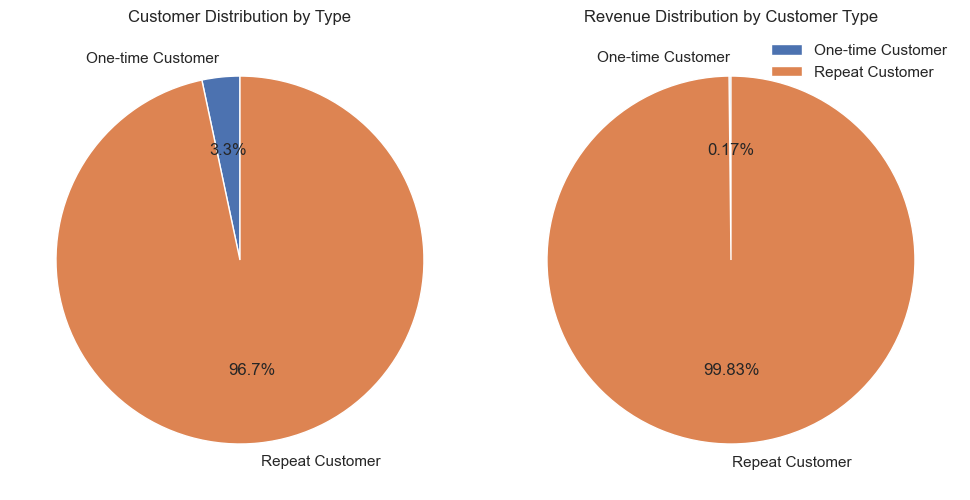

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

#Customer Share 
axes[0].pie(
    customer_type_summary["customer_share"],
    labels=customer_type_summary["customer_type"],
    autopct="%.1f%%",
    startangle=90
)
axes[0].set_title("Customer Distribution by Type")

#Revenue Share
axes[1].pie(
    customer_type_summary["revenue_share"],
    labels=customer_type_summary["customer_type"],
    autopct="%.2f%%",
    startangle=90
)
axes[1].set_title("Revenue Distribution by Customer Type")

plt.legend()
plt.tight_layout()
plt.show()

- The customer base is highly repeat-oriented. Approximately 96.7% of customers are repeat customers, and they generate 99.8% of total revenue. One-time customers represent only 3.3% of the customer base and contribute just 0.17% of revenue.

- This indicates strong customer retention and a high reliance on repeat purchases for revenue generation.

### 3.3 Customer Profitability — Revenue vs Profit

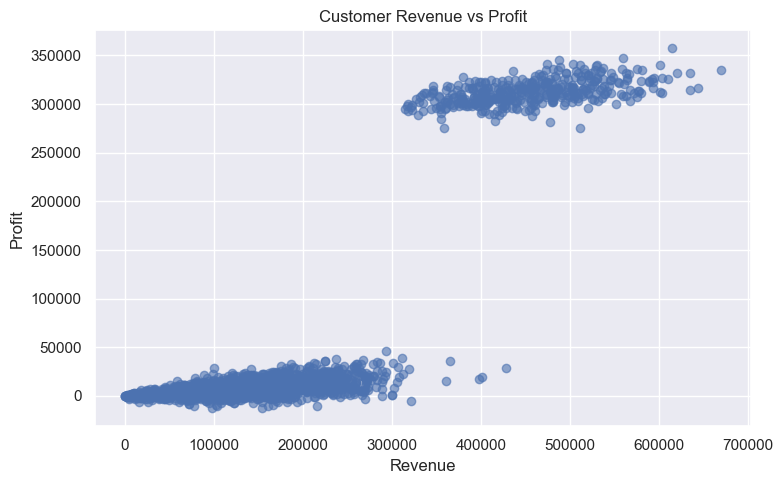

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(
    customer_performance["revenue"],
    customer_performance["profit"],
    alpha=0.6
)

plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.title("Customer Revenue vs Profit")

plt.tight_layout()
plt.show()

- Customer revenue and profit show a generally positive relationship, indicating that higher-revenue customers tend to generate higher profits.
- However, the customer base is divided into two clearly separated groups. Most customers generate relatively moderate revenue and profit, while a smaller group shows exceptionally high profitability. 
- Given the previously identified anomalies in the 2026 data, these extreme values should be investigated before interpreting them as genuine high-value customers.

## 4.  Operational Analysis

### 4.1 Payment methods   

In [3]:
payment_method_performance = sales.groupby("payment_method").agg(
    orders=("order_id", "nunique"),
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    customers=("customer_id", "nunique")
).reset_index()

payment_method_performance["order_share"] = (
    payment_method_performance["orders"]
    / payment_method_performance["orders"].sum() * 100
)

payment_method_performance["revenue_share"] = (
    payment_method_performance["revenue"]
    / payment_method_performance["revenue"].sum() * 100
)

payment_method_performance["profit_margin"] = (
    payment_method_performance["profit"]
    / payment_method_performance["revenue"] * 100
)

payment_method_performance["aov"] = (
    payment_method_performance["revenue"]
    / payment_method_performance["orders"]
)

payment_method_performance.sort_values("revenue", ascending=False)

,payment_method,orders,revenue,profit,customers,order_share,revenue_share,profit_margin,aov
4,In-App Wallet,7642,1.955060e+08,1.256194e+08,1846,28.486227,49.412681,64.253512,25583.089100
1,Cash,6353,6.705937e+07,4.276716e+06,1794,23.681366,16.948757,6.377507,10555.543132
3,Debit Card,6219,6.667289e+07,4.416748e+06,1805,23.181869,16.851078,6.624504,10720.837622
2,Credit Card,6211,6.640498e+07,4.344372e+06,1803,23.152048,16.783365,6.542238,10691.511459
0,BNPL,402,1.630110e+04,-1.835130e+04,402,1.498490,0.004120,-112.577065,40.550000


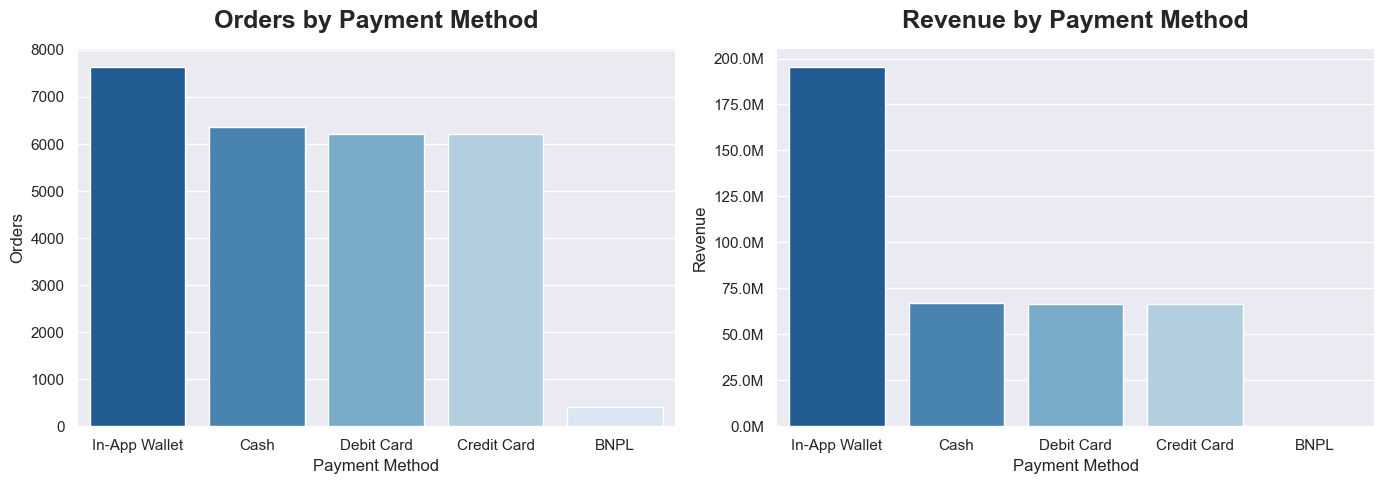

In [4]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

#orders
plot_df = payment_method_performance.sort_values("orders", ascending=False)

ax = sns.barplot(
    data=plot_df,
    x="payment_method",
    y="orders",
    palette="Blues_r",
    hue="payment_method",
    legend=False,
    ax=axes[0]
)

ax.set_title("Orders by Payment Method", fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Payment Method")
ax.set_ylabel("Orders")

#revenue
plot_df = payment_method_performance.sort_values("revenue", ascending=False)

ax = sns.barplot(
    data=plot_df,
    x="payment_method",
    y="revenue",
    palette="Blues_r",
    hue="payment_method",
    legend=False,
    ax=axes[1]
)

ax.set_title("Revenue by Payment Method", fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Payment Method")
ax.set_ylabel("Revenue")

axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

- Payment performance is highly differentiated across payment methods. **Cash, Debit Card, and Credit Card** show similar order volumes, revenue contributions, average order values, and profit margins.
- In contrast, **In-App Wallet** generates approximately 49.4% of total revenue and 125.6M in profit despite accounting for only about 28.5% of orders. Its average order value is also substantially higher than other payment methods.
- BNPL shows an extreme negative margin; however, this result is driven by the previously identified **LittleStar Sweater anomaly** on 2026-02-20. Therefore, the poor BNPL performance should not be interpreted as an inherent characteristic of the payment method without further data validation.

## 5. Order Behavior Analysis 

In [ ]:
order_behavior = sales.groupby("order_id").agg(
    units_sold=("quantity", "sum"),
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    customer_id=("customer_id", "first")
).reset_index()

order_behavior.head()

,order_id,units_sold,revenue,profit,customer_id
0,1,21,12122.92,3992.60,366
1,2,36,6832.27,1530.76,1836
2,3,19,1656.76,-64.39,480
3,4,59,27411.66,6565.07,1107
4,5,26,11777.68,2561.37,1199


### 5.1 Distribution of Order Size

In [22]:
order_behavior["units_sold"].describe()

count    26827.000000
mean        29.202445
std         17.937225
min          1.000000
25%         16.000000
50%         27.000000
75%         39.000000
max         91.000000
Name: units_sold, dtype: float64

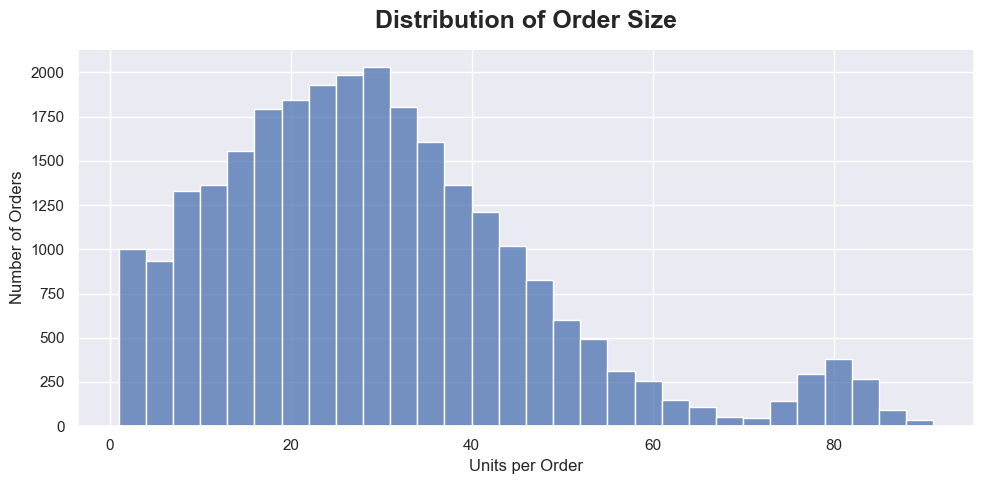

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=order_behavior,
    x="units_sold",
    bins=30
)

plt.title("Distribution of Order Size", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Units per Order")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### 5.2 Order Size vs Profitability

C:\Users\kavoshrayan\AppData\Local\Temp\ipykernel_5356\2071636774.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


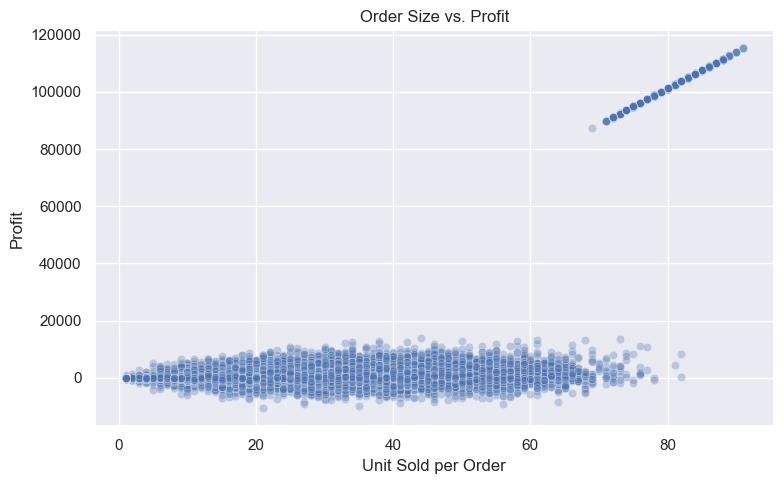

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=order_behavior,
    x="units_sold",
    y="profit",
    alpha=0.3
)

plt.title("Order Size vs. Profit")
plt.xlabel("Unit Sold per Order")
plt.ylabel("Profit")

plt.legend()
plt.tight_layout()
plt.show()

- For most orders, increasing the number of items does not result in a significant increas in profit.
- However, for large orders, profit increases linearly.
- What distinguishes these high-volume, high-profit orders from the rest?

In [5]:
large_order_ids = order_behavior.loc[
    order_behavior["units_sold"] >= 70,
    "order_id"
]

large_orders = sales[sales["order_id"].isin(large_order_ids)]

large_orders = large_orders.groupby("order_id").agg(
    units_sold=("quantity", "sum"),
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    payment_method=("payment_method", "first"),
    priority=("order_priority", "first"),
    status=("order_status", "first"),
    discount=("discount", "first")
)

large_orders["profit_margin"] = (
    large_orders["profit"] / large_orders["revenue"] * 100
)

large_orders["revenue_per_unit"] = (
    large_orders["revenue"] / large_orders["units_sold"]
)

large_orders["profit_per_unit"] = (
    large_orders["profit"] / large_orders["units_sold"]
)

large_orders.head()

NameError: name 'order_behavior' is not defined

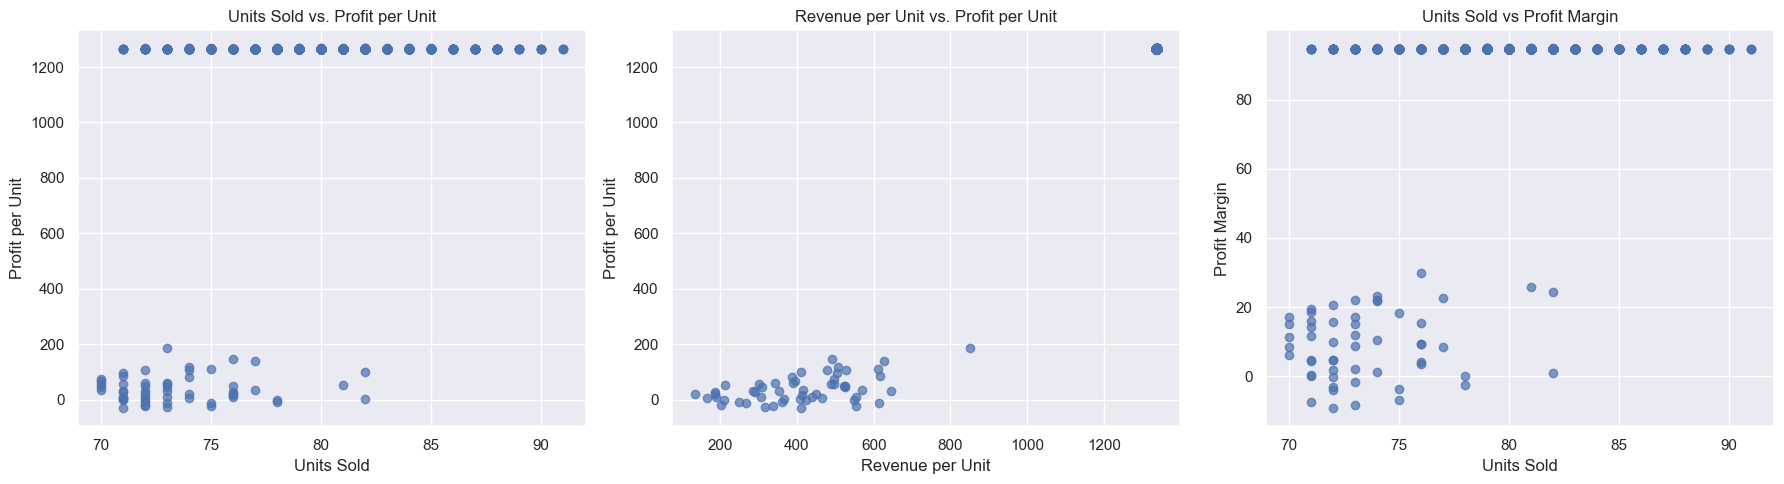

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Units Sold vs Profit per Unit
axes[0].scatter(large_orders["units_sold"], large_orders["profit_per_unit"], alpha=0.7)
axes[0].set_title("Units Sold vs. Profit per Unit")
axes[0].set_xlabel("Units Sold")
axes[0].set_ylabel("Profit per Unit")

# Revenue per Unit vs Profit per Unit
axes[1].scatter(large_orders["revenue_per_unit"], large_orders["profit_per_unit"], alpha=0.7)
axes[1].set_title("Revenue per Unit vs. Profit per Unit")
axes[1].set_xlabel("Revenue per Unit")
axes[1].set_ylabel("Profit per Unit")

# Units Sold vs Profit Margin
axes[2].scatter(large_orders["units_sold"], large_orders["profit_margin"], alpha=0.7)
axes[2].set_title("Units Sold vs Profit Margin")
axes[2].set_xlabel("Units Sold")
axes[2].set_ylabel("Profit Margin")

plt.tight_layout()
plt.show()

- Large orders (70+ units) do not exhibit a clear relationship between order size and profitability per unit or profit margin.
- Instead, profitability appears to be more strongly associated with the revenue generated per unit. This suggests that the unusually high profits observed in this group are likely driven by the economic value and margin of the items in the order rather than order volume alone.

## 6. Business Insights

The analysis reveals several important patterns in DBKala's sales and profitability performance:

### 1. Overall profitability is strong, but highly influenced by unusual 2026 results

The business generated approximately 395.7M in revenue and 138.6M in profit, resulting in an overall profit margin of 35.04%. However, the 2026 results show an unusually large increase in profit compared with previous years. This is strongly associated with previously identified data anomalies and should therefore be interpreted with caution.

### 2. Profitability is concentrated among a small group of products

A small number of products, particularly NitroBlade Ultra, SurfaceBook Pro, SurfaceBook Vision, MacBook Vision, and SurfaceBook Infinity, account for a substantial share of total profit.

These products should receive particular attention in pricing, inventory, and margin monitoring decisions.

### 3. Some products generate persistent losses

LittleStar Sweater is the most significant loss-making product. Nearly 78% of its transactions occur below cost, indicating a structural profitability problem rather than an isolated loss.

This suggests that pricing, cost, or product-level business rules should be reviewed before continuing to scale sales of this product.

### 4. Customer revenue is relatively diversified, but repeat customers are highly important

The top 10% of customers generate approximately 25.7% of total revenue, while the bottom 50% contribute approximately 22.8%. This indicates that revenue is not excessively dependent on a small number of customers.

At the same time, repeat customers account for approximately 99.8% of total revenue, highlighting the importance of customer retention and repeat purchasing behavior.

### 5. Payment method performance is highly differentiated

In-App Wallet generates approximately 49.4% of total revenue and 125.6M in profit while representing only about 28.5% of orders. Its average order value is substantially higher than the other payment methods.

However, the extreme performance differences should be interpreted carefully because some results are affected by the identified 2026 anomalies.

### 6. Large order volume alone does not explain high profitability

For large orders with 70 or more units, increasing order size does not show a clear relationship with profit margin or profit per unit.

Instead, higher profitability appears to be more closely associated with higher revenue per unit. This suggests that the economic value and margin of the items in an order are more important than order volume alone.

## 7. Recommendations

Based on the findings of the analysis, the following actions are recommended:

### 1. Investigate and correct the 2026 data anomalies

The unusually high profitability observed in 2026 has a substantial impact on overall business metrics and product-level profitability.

Before making pricing, product, or strategic decisions, the underlying pricing and cost data for the affected records should be validated.

### 2. Review the pricing and cost structure of loss-making products

Products such as LittleStar Sweater should be reviewed for pricing, procurement cost, discount policy, and inventory strategy.

Products that repeatedly sell below cost should not be scaled without first identifying and addressing the underlying cause.

### 3. Protect and monitor high-profit products

High-volume, high-margin products should receive priority in inventory planning and profitability monitoring.

Because a relatively small group of products contributes a large share of total profit, disruptions in these products could have a significant impact on overall business performance.

### 4. Use customer retention as a key growth strategy

Since repeat customers generate the vast majority of revenue, customer retention should remain a major business priority.

Personalized offers, loyalty programs, and targeted campaigns can be used to encourage repeat purchases while maintaining healthy margins.

### 5. Monitor payment-method profitability

In-App Wallet demonstrates substantially higher revenue, AOV, and profitability than other payment methods.

The business should investigate what drives the higher-value orders associated with this payment method and consider strategies to encourage its adoption, while separately reviewing the economics of BNPL.

### 6. Evaluate orders based on value, not only volume

Large orders should not automatically be considered highly profitable.

Order-level decisions should consider revenue per unit and profit margin in addition to the number of units sold, since order volume alone does not explain profitability differences.

### 7. Establish ongoing profitability monitoring

A recurring dashboard should track:

- Revenue
- Profit
- Profit Margin
- Loss Rate
- Product-level profitability
- Customer revenue contribution
- Payment-method performance
- Large-order profitability

This would help identify profitability deterioration and unusual patterns earlier.